In [89]:

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

# Specify the path to your CSV file in Google Drive
# Replace 'path/to/your/file.csv' with the actual path to your dataset
drive_file_path = '/content/drive/MyDrive/BDA PROJECT/zomato.csv'

# Load the dataset into a pandas DataFrame
try:
    df = pd.read_csv(drive_file_path)
    print("Dataset loaded successfully from Google Drive!")
    # Display the first 5 rows of the DataFrame
    display(df_drive.head())
except FileNotFoundError:
    print(f"Error: The file at '{drive_file_path}' was not found. Please check the path and try again.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully from Google Drive!
An error occurred while loading the dataset: name 'df_drive' is not defined


## 1. Initial Data Loading and Inspection

In [90]:
import pandas as pd
import numpy as np
import ast
import re

# Mount Google Drive if not already mounted (usually done at the beginning of the notebook)
# from google.colab import drive
# drive.mount('/content/drive')

# Specify the path to your CSV file in Google Drive
drive_file_path = '/content/drive/MyDrive/BDA PROJECT/zomato.csv'

# Load the dataset into a pandas DataFrame
try:
    df = pd.read_csv(drive_file_path)
    print("Dataset loaded successfully from Google Drive!")
    # Display the first 5 rows of the DataFrame
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file at '{drive_file_path}' was not found. Please check the path and try again.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

print("\nDataFrame Information:")
df.info()

print("\nDataFrame Descriptive Statistics:")
display(df.describe(include='all'))

print("\nInitial Null Counts:")
display(df.isnull().sum())

print("\nInitial Duplicated Rows:")
print(df.duplicated().sum())

print("\nCurrent DataFrame Shape:")
print(df.shape)

Dataset loaded successfully from Google Drive!


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari



DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
count,51717,51717,51717,51717,51717,43942,51717.000000,50509,51696,51490,23639,51672,51371,51717,51717,51717,51717
unique,51717,11495,8792,2,2,64,NaN,14926,93,93,5271,2723,70,22513,9098,7,30
top,https://www.zomato.com/bangalore/the-nest-the-...,Delivery Only,Cafe Coffee Day,Yes,No,NEW,NaN,080 43334321,BTM,Quick Bites,Biryani,North Indian,300,[],[],Delivery,BTM
freq,1,128,96,30444,45268,2208,NaN,216,5124,19132,182,2913,7576,7595,39617,25942,3279
mean,NaN,NaN,NaN,NaN,NaN,NaN,283.697527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,803.838853,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,7.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,41.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,198.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Initial Null Counts:


,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
phone,1208
location,21
rest_type,227



Initial Duplicated Rows:
0

Current DataFrame Shape:
(51717, 17)


## 2. Drop Unnecessary Columns

In [91]:
drop_cols = [
    "url",
    "address",
    "phone"
]

df.drop(columns=drop_cols, inplace=True)

print(f"Columns dropped. New DataFrame shape: {df.shape}")
print("\nNull counts after dropping columns:")
display(df.isnull().sum())

Columns dropped. New DataFrame shape: (51717, 14)

Null counts after dropping columns:


,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
location,21
rest_type,227
dish_liked,28078
cuisines,45
approx_cost(for two people),346


## 3. Clean and Standardize Individual Columns

### 3.1. Cleaning 'name' Column

In [92]:
# Convert to string
df["name"] = df["name"].astype(str)

# Remove leading/trailing spaces
df["name"] = df["name"].str.strip()

# Replace newlines with spaces
df["name"] = df["name"].str.replace("\n", " ", regex=False)

# Remove multiple spaces
df["name"] = df["name"].str.replace(r"\s+", " ", regex=True)

# Remove unwanted quotes at the beginning/end
df["name"] = df["name"].str.strip("'\"")

# Fix common encoding issue
df["name"] = df["name"].str.replace("Ã", "", regex=False)

# Replace invalid names with NaN instead of dropping immediately
invalid_pattern = (
    r"^(Rated|RATED)|" # Starts with Rated or RATED
    r"^(service|taste|ambience|quantity|ordered|delivery|review)$" # Specific keywords
)

df.loc[
    df["name"].str.contains(invalid_pattern, case=False, na=False),
    "name"
] = np.nan

# Replace very short names (less than 2 characters) with NaN
df.loc[df["name"].str.len() < 2, "name"] = np.nan

# Replace very long names (more than 80 characters) with NaN
df.loc[df["name"].str.len() > 80, "name"] = np.nan

# Drop only rows where name is missing
df.dropna(subset=["name"], inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

print(f"'name' column cleaned. New DataFrame shape: {df.shape}")
print("\nNull counts after cleaning 'name' column:")
display(df.isnull().sum())
display(df.head())

'name' column cleaned. New DataFrame shape: (51709, 14)

Null counts after cleaning 'name' column:


/tmp/ipykernel_621/3905964919.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["name"].str.contains(invalid_pattern, case=False, na=False),


,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
location,21
rest_type,227
dish_liked,28075
cuisines,45
approx_cost(for two people),346


,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


### 3.2. Cleaning 'online_order' Column

In [93]:
# Convert to string
df["online_order"] = df["online_order"].astype(str)

# Remove leading/trailing spaces
df["online_order"] = df["online_order"].str.strip()

# Standardize case
df["online_order"] = df["online_order"].str.title()

# Replace common missing values with NaN
df["online_order"] = df["online_order"].replace(
    ["Nan", "None", "N/A", "-", ""],
    pd.NA
)

# Keep only valid values (Yes/No) - this will drop rows with invalid values
df = df[df["online_order"].isin(["Yes", "No"])]

# Reset index
df.reset_index(drop=True, inplace=True)

print(f"'online_order' column cleaned. New DataFrame shape: {df.shape}")
print("Unique values in 'online_order' after cleaning:")
print(df["online_order"].unique())
print("Value counts in 'online_order' after cleaning:")
print(df["online_order"].value_counts())
print("\nNull counts after cleaning 'online_order' column:")
display(df.isnull().sum())

'online_order' column cleaned. New DataFrame shape: (51709, 14)
Unique values in 'online_order' after cleaning:
['Yes' 'No']
Value counts in 'online_order' after cleaning:
online_order
Yes    30437
No     21272
Name: count, dtype: int64

Null counts after cleaning 'online_order' column:


,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
location,21
rest_type,227
dish_liked,28075
cuisines,45
approx_cost(for two people),346


### 3.3. Cleaning 'book_table' Column

In [94]:
# Convert to string
df["book_table"] = df["book_table"].astype(str)

# Remove leading/trailing spaces
df["book_table"] = df["book_table"].str.strip()

# Standardize case
df["book_table"] = df["book_table"].str.title()

# Replace common missing values with NaN
df["book_table"] = df["book_table"].replace(
    ["Nan", "None", "N/A", "-", ""],
    pd.NA
)

# Keep only valid values (Yes/No) - this will drop rows with invalid values
df = df[df["book_table"].isin(["Yes", "No"])]

# Reset index
df.reset_index(drop=True, inplace=True)

print(f"'book_table' column cleaned. New DataFrame shape: {df.shape}")
print("Unique values in 'book_table' after cleaning:")
print(df["book_table"].unique())
print("Value counts in 'book_table' after cleaning:")
print(df["book_table"].value_counts())
print("\nNull counts after cleaning 'book_table' column:")
display(df.isnull().sum())

'book_table' column cleaned. New DataFrame shape: (51709, 14)
Unique values in 'book_table' after cleaning:
['Yes' 'No']
Value counts in 'book_table' after cleaning:
book_table
No     45261
Yes     6448
Name: count, dtype: int64

Null counts after cleaning 'book_table' column:


,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
location,21
rest_type,227
dish_liked,28075
cuisines,45
approx_cost(for two people),346


### 3.4. Cleaning 'rate' Column

In [95]:
# Convert to string and strip whitespace
df["rate"] = df["rate"].astype(str).str.strip()

# Create an indicator for missing rate before imputation and further processing
df['rate_is_missing'] = df['rate'].isna().astype(int) # Check initial NaNs

# Replace common non-numeric/missing string representations with NaN
df["rate"] = df["rate"].replace(
    [
        "",
        " ",
        "NEW",
        "new",
        "nan",
        "NaN",
        "None",
        "NULL",
        "null",
        "<NA>",
        "-"
    ],
    np.nan
)

# Extract only rating like 4.1 or 3.8 from any text
df["rate"] = df["rate"].str.extract(r'([0-5](?:\.\d)?)')

# Convert to numeric, coercing errors to NaN
df["rate"] = pd.to_numeric(df["rate"], errors="coerce")

# Keep only ratings between 0 and 5, set others to NaN
df.loc[(df["rate"] < 0) | (df["rate"] > 5), "rate"] = np.nan

# Calculate median for imputation *after* initial cleaning and extraction
median_rating_for_imputation = df["rate"].median()

# Fill all remaining missing values with the median
df["rate"] = df["rate"].fillna(median_rating_for_imputation)

# Round to one decimal place
df["rate"] = df["rate"].round(1)

# Final datatype
df["rate"] = df["rate"].astype(float)

print(f"'rate' column cleaned. New DataFrame shape: {df.shape}")
print("Description of 'rate' column after cleaning:")
print(df["rate"].describe())
print("Unique Ratings after cleaning:")
print(sorted(df["rate"].unique()))
print("Value counts for rate_is_missing:")
print(df['rate_is_missing'].value_counts())
print("\nNull counts after cleaning 'rate' column:")
display(df.isnull().sum())

'rate' column cleaned. New DataFrame shape: (51709, 15)
Description of 'rate' column after cleaning:
count    51709.000000
mean         3.700323
std          0.395394
min          1.800000
25%          3.500000
50%          3.700000
75%          3.900000
max          4.900000
Name: rate, dtype: float64
Unique Ratings after cleaning:
[np.float64(1.8), np.float64(2.0), np.float64(2.1), np.float64(2.2), np.float64(2.3), np.float64(2.4), np.float64(2.5), np.float64(2.6), np.float64(2.7), np.float64(2.8), np.float64(2.9), np.float64(3.0), np.float64(3.1), np.float64(3.2), np.float64(3.3), np.float64(3.4), np.float64(3.5), np.float64(3.6), np.float64(3.7), np.float64(3.8), np.float64(3.9), np.float64(4.0), np.float64(4.1), np.float64(4.2), np.float64(4.3), np.float64(4.4), np.float64(4.5), np.float64(4.6), np.float64(4.7), np.float64(4.8), np.float64(4.9)]
Value counts for rate_is_missing:
rate_is_missing
0    51709
Name: count, dtype: int64

Null counts after cleaning 'rate' column:


,0
name,0
online_order,0
book_table,0
rate,0
votes,0
location,21
rest_type,227
dish_liked,28075
cuisines,45
approx_cost(for two people),346


### 3.5. Cleaning 'votes' Column

In [96]:
# Convert to string
df["votes"] = df["votes"].astype(str).str.strip()

# Keep only values that are purely digits
mask = df["votes"].str.fullmatch(r"\d+")

# Invalid values become NaN
df.loc[~mask, "votes"] = np.nan

# Convert to numeric
df["votes"] = pd.to_numeric(df["votes"], errors="coerce")

# Fill missing values with median
median_votes = int(df["votes"].median())
df["votes"] = df["votes"].fillna(median_votes)

# Integer datatype
df["votes"] = df["votes"].astype(int)

print(f"'votes' column cleaned. New DataFrame shape: {df.shape}")
print("Description of 'votes' column after cleaning:")
print(df["votes"].describe())
print("\nNull counts after cleaning 'votes' column:")
display(df.isnull().sum())

'votes' column cleaned. New DataFrame shape: (51709, 15)
Description of 'votes' column after cleaning:
count    51709.000000
mean       283.705235
std        803.895150
min          0.000000
25%          7.000000
50%         41.000000
75%        198.000000
max      16832.000000
Name: votes, dtype: float64

Null counts after cleaning 'votes' column:


,0
name,0
online_order,0
book_table,0
rate,0
votes,0
location,21
rest_type,227
dish_liked,28075
cuisines,45
approx_cost(for two people),346


### 3.6. Cleaning 'location' Column

In [97]:
# Convert to string
df["location"] = df["location"].astype(str).str.strip()

# Replace common missing values
df["location"] = df["location"].replace(
    [
        "",
        " ",
        "nan",
        "NaN",
        "None",
        "NULL",
        "null",
        "<NA>",
        "-"
    ],
    np.nan
)

# Standardize capitalization
df["location"] = df["location"].str.title()

# Define a list of valid Bangalore locations (from previous context)
valid_locations = [
    "Banashankari", "Basavanagudi", "Mysore Road", "Jayanagar", "Kumaraswamy Layout",
    "Rajarajeshwari Nagar", "Vijay Nagar", "Uttarahalli", "JP Nagar", "South Bangalore",
    "City Market", "Nagarbhavi", "Bannerghatta Road", "BTM", "Kanakapura Road",
    "Bommanahalli", "CV Raman Nagar", "Electronic City", "HSR", "Marathahalli",
    "Sarjapur Road", "Wilson Garden", "Shanti Nagar", "Koramangala 5th Block",
    "Koramangala 8th Block", "Richmond Road", "Koramangala 7th Block", "Jalahalli",
    "Koramangala 4th Block", "Bellandur", "Whitefield", "East Bangalore", "Old Airport Road",
    "Indiranagar", "Koramangala 1st Block", "Frazer Town", "RT Nagar", "MG Road",
    "Brigade Road", "Lavelle Road", "Church Street", "Ulsoor", "Residency Road",
    "Shivajinagar", "Infantry Road", "St. Marks Road", "Cunningham Road", "Race Course Road",
    "Commercial Street", "Vasanth Nagar", "HBR Layout", "Domlur", "Ejipura",
    "Jeevan Bhima Nagar", "Old Madras Road", "Malleshwaram", "Seshadripuram",
    "Kammanahalli", "Koramangala 6th Block", "Majestic", "Langford Town", "Central Bangalore",
    "Sanjay Nagar", "Brookefield", "ITPL Main Road, Whitefield",
    "Varthur Main Road, Whitefield", "KR Puram", "Koramangala 2nd Block",
    "Koramangala 3rd Block", "Koramangala", "Hosur Road", "Rajajinagar", "Banaswadi",
    "North Bangalore", "Nagawara", "Hennur", "Kalyan Nagar", "New BEL Road", "Jakkur",
    "Rammurthy Nagar", "Thippasandra", "Kaggadasapura", "Hebbal", "Kengeri",
    "Sankey Road", "Sadashiv Nagar", "Basaveshwara Nagar", "Yeshwantpur",
    "West Bangalore", "Magadi Road", "Yelahanka", "Sahakara Nagar", "Peenya"
]

# Keep only valid locations, set others to NaN
df.loc[~df["location"].isin(valid_locations), "location"] = np.nan

# Fill missing values with most frequent location
mode_location = df["location"].mode()[0]
df["location"] = df["location"].fillna(mode_location)

# Convert to category
df["location"] = df["location"].astype("category")

print(f"'location' column cleaned. New DataFrame shape: {df.shape}")
print("Value counts for 'location' after cleaning:")
print(df["location"].value_counts())
print("Missing Values in 'location' after cleaning:", df["location"].isna().sum())
print("Unique Locations after cleaning:", df["location"].nunique())
print("\nNull counts after cleaning 'location' column:")
display(df.isnull().sum())

'location' column cleaned. New DataFrame shape: (51709, 15)
Value counts for 'location' after cleaning:
location
Whitefield              21800
Indiranagar              2083
Jayanagar                1926
Marathahalli             1846
Bannerghatta Road        1630
                        ...  
West Bangalore              6
Yelahanka                   6
Jakkur                      3
Rajarajeshwari Nagar        2
Peenya                      1
Name: count, Length: 75, dtype: int64
Missing Values in 'location' after cleaning: 0
Unique Locations after cleaning: 75

Null counts after cleaning 'location' column:


,0
name,0
online_order,0
book_table,0
rate,0
votes,0
location,0
rest_type,227
dish_liked,28075
cuisines,45
approx_cost(for two people),346


### 3.7. Cleaning 'rest_type' Column and Handling Nulls

In [98]:
valid_rest_types = [
    "Bakery", "Bar", "Beverage Shop", "Bhojanalya", "Cafe", "Casual Dining",
    "Club", "Confectionery", "Delivery", "Dessert Parlor", "Dhaba", "Fine Dining",
    "Food Court", "Food Truck", "Irani Cafee", "Kiosk", "Lounge", "Meat Shop",
    "Mess", "Microbrewery", "Pop Up", "Pub", "Quick Bites", "Sweet Shop", "Takeaway"
]

df["rest_type"] = (
    df["rest_type"]
    .astype(str)
    .str.strip()
    .replace(["", "nan", "Nan", "None", "N/A", "-", "NULL"], pd.NA)
)

pattern = r"Rated|RATED|\(|\)|\"|'|\n"
df.loc[df["rest_type"].str.contains(pattern, case=False, na=False), "rest_type"] = pd.NA

def clean_rest_type_list(x):
    if pd.isna(x):
        return pd.NA
    parts = [p.strip() for p in str(x).split(",")]
    parts = [p for p in parts if p in valid_rest_types]
    return ", ".join(parts) if parts else pd.NA

df["rest_type"] = df["rest_type"].apply(clean_rest_type_list)
df["rest_type"] = df["rest_type"].str.replace(r"\s*,\s*", ", ", regex=True).str.strip()

# Drop rows where 'rest_type' is null as per user request
df.dropna(subset=['rest_type'], inplace=True)

print(f"'rest_type' column cleaned and nulls dropped. New DataFrame shape: {df.shape}")
print("Value counts for 'rest_type' after cleaning:")
print(df["rest_type"].value_counts(dropna=False))
print("\nNull counts after cleaning 'rest_type' column:")
display(df.isnull().sum())

'rest_type' column cleaned and nulls dropped. New DataFrame shape: (51482, 15)
Value counts for 'rest_type' after cleaning:
rest_type
Quick Bites                   19132
Casual Dining                 10330
Cafe                           3729
Delivery                       2603
Dessert Parlor                 2262
                              ...  
Dessert Parlor, Kiosk             2
Dessert Parlor, Food Court        2
Food Court, Beverage Shop         2
Sweet Shop, Dessert Parlor        1
Quick Bites, Kiosk                1
Name: count, Length: 93, dtype: int64

Null counts after cleaning 'rest_type' column:


,0
name,0
online_order,0
book_table,0
rate,0
votes,0
location,0
rest_type,0
dish_liked,27918
cuisines,24
approx_cost(for two people),323


### 3.8. Cleaning 'dish_liked' Column and Imputing Nulls

In [99]:
df["dish_liked"] = df["dish_liked"].astype(str).str.strip()

# Missing values
df["dish_liked"] = df["dish_liked"].replace(
    ["", "nan", "None", "NaN", "N/A", "-"],
    pd.NA
)

# Remove ratings
df["dish_liked"] = df["dish_liked"].str.replace(
    r".*Rated\s*\d+(?:\.\d+)?['\"]?\)?",
    "",
    regex=True
)

# Remove review text
df["dish_liked"] = df["dish_liked"].str.replace(
    r"(?is)^.*RATED.*",
    "",
    regex=True
)

# Remove encoding issues
df["dish_liked"] = df["dish_liked"].str.replace(
    r"[ÃÂ]+",
    "",
    regex=True
)

# Remove newlines
df["dish_liked"] = df["dish_liked"].str.replace(r"\n", " ", regex=True)

# Remove long reviews/non-dish content
def clean_dishes(x):
    if pd.isna(x):
        return pd.NA

    x = str(x).strip()

    # If the cleaned string is empty, return NA
    if not x:
        return pd.NA

    # Heuristic to identify non-dish content (e.g., full reviews, very long text)
    if len(x.split()) > 25: # More than 25 words is likely a review
        return pd.NA

    if any(ch in x for ch in [".", "!", "?"]): # Contains punctuation indicative of sentences
        return pd.NA

    return x

df["dish_liked"] = df["dish_liked"].apply(clean_dishes)

# Remove duplicate commas and strip extraneous commas
df["dish_liked"] = (
    df["dish_liked"]
    .str.replace(r",\s*,", ", ", regex=True)
    .str.strip(", ")
)

# Convert empty strings to NaN again after final cleaning
df["dish_liked"] = df["dish_liked"].replace("", pd.NA)

# Impute 'dish_liked' with 'No Dish Liked' as per user request
df['dish_liked'].fillna('No Dish Liked', inplace=True)

print(f"'dish_liked' column cleaned and nulls imputed. New DataFrame shape: {df.shape}")
print("Nulls in 'dish_liked' after imputation:", df['dish_liked'].isnull().sum())
print("\nNull counts after cleaning 'dish_liked' column:")
display(df.isnull().sum())

'dish_liked' column cleaned and nulls imputed. New DataFrame shape: (51482, 15)
Nulls in 'dish_liked' after imputation: 0

Null counts after cleaning 'dish_liked' column:


/tmp/ipykernel_621/2783098423.py:66: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['dish_liked'].fillna('No Dish Liked', inplace=True)


,0
name,0
online_order,0
book_table,0
rate,0
votes,0
location,0
rest_type,0
dish_liked,0
cuisines,24
approx_cost(for two people),323


### 3.9. Cleaning 'cuisines' Column and Handling Nulls

In [100]:
# Convert to string
df["cuisines"] = df["cuisines"].astype(str).str.strip()

# Replace fake missing values
df["cuisines"] = df["cuisines"].replace(
    ["", "nan", "None", "NaN", "N/A"],
    np.nan
)

# Remove review text or other non-cuisine content
mask = (
    df["cuisines"].str.contains("rated", case=False, na=False) |
    df["cuisines"].str.contains("\n", na=False)
)
df.loc[mask, "cuisines"] = np.nan

# Remove quotes and brackets
df["cuisines"] = (
    df["cuisines"]
      .str.replace("'", "", regex=False)
      .str.replace('"', "", regex=False)
      .str.replace("(", "", regex=False)
      .str.replace(")", "", regex=False)
)

# Remove duplicate cuisines within a string
def remove_duplicate_cuisines(text):
    if pd.isna(text):
        return text

    cuisines = [x.strip() for x in text.split(",")]
    cuisines = list(dict.fromkeys(cuisines)) # Remove duplicates while preserving order
    return ", ".join(cuisines)

df["cuisines"] = df["cuisines"].apply(remove_duplicate_cuisines)

# Standardize spacing
df["cuisines"] = (
    df["cuisines"]
      .str.replace(r"\s*,\s*", ", ", regex=True) # Replace multiple spaces around comma with single comma space
      .str.strip(", ") # Strip leading/trailing commas and spaces
)

# Standardize capitalization (e.g., Title Case for each cuisine)
df["cuisines"] = df["cuisines"].apply(
    lambda x: ", ".join(i.strip().title() for i in x.split(","))
    if pd.notna(x) else x
)

# Keep only valid cuisine strings (alphabetic, ampersands, hyphens, commas, spaces)
pattern = r"^[A-Za-z&\-\s,]+$"
df.loc[~df["cuisines"].str.match(pattern, na=False), "cuisines"] = np.nan

# Drop rows where 'cuisines' is null as per user request
df.dropna(subset=['cuisines'], inplace=True)

print(f"'cuisines' column cleaned and nulls dropped. New DataFrame shape: {df.shape}")
print("Unique values in 'cuisines' after cleaning:")
print(df["cuisines"].nunique())
print("\nNull counts after cleaning 'cuisines' column:")
display(df.isnull().sum())

'cuisines' column cleaned and nulls dropped. New DataFrame shape: (51458, 15)
Unique values in 'cuisines' after cleaning:
2710

Null counts after cleaning 'cuisines' column:


,0
name,0
online_order,0
book_table,0
rate,0
votes,0
location,0
rest_type,0
dish_liked,0
cuisines,0
approx_cost(for two people),318


### 3.10. Cleaning 'approx_cost(for two people)' Column (Renamed to 'approx_cost')

In [101]:
# Rename column
df.rename(columns={
    "approx_cost(for two people)": "approx_cost"
}, inplace=True)

# Convert to string
df["approx_cost"] = df["approx_cost"].astype(str)

# Remove commas (e.g., '1,000' -> '1000')
df["approx_cost"] = df["approx_cost"].str.replace(",", "", regex=False)

# Remove leading/trailing spaces
df["approx_cost"] = df["approx_cost"].str.strip()

# Convert valid numbers, invalid values become NaN
df["approx_cost"] = pd.to_numeric(df["approx_cost"], errors="coerce")

# Fill missing values with median
df["approx_cost"] = df["approx_cost"].fillna(df["approx_cost"].median())

# Convert to integer
df["approx_cost"] = df["approx_cost"].astype(int)

print(f"'approx_cost' column cleaned. New DataFrame shape: {df.shape}")
print("Description of 'approx_cost' column after cleaning:")
print(df["approx_cost"].describe())
print("Nulls in 'approx_cost' after cleaning:", df["approx_cost"].isna().sum())
print("\nNull counts after cleaning 'approx_cost' column:")
display(df.isnull().sum())

'approx_cost' column cleaned. New DataFrame shape: (51458, 15)
Description of 'approx_cost' column after cleaning:
count    51458.000000
mean       555.061895
std        438.365985
min         40.000000
25%        300.000000
50%        400.000000
75%        650.000000
max       6000.000000
Name: approx_cost, dtype: float64
Nulls in 'approx_cost' after cleaning: 0

Null counts after cleaning 'approx_cost' column:


,0
name,0
online_order,0
book_table,0
rate,0
votes,0
location,0
rest_type,0
dish_liked,0
cuisines,0
approx_cost,0


### 3.11. Cleaning 'reviews_list' Column and Imputing Nulls

In [102]:
def clean_reviews_list(reviews_str):
    if pd.isna(reviews_str) or reviews_str == '[]':
        return pd.NA # Use pd.NA for explicitly missing/empty values

    # Ensure it's a string before literal_eval
    if not isinstance(reviews_str, str):
        return pd.NA # Non-string type, return NA

    try:
        reviews_list = ast.literal_eval(reviews_str)
    except (ValueError, SyntaxError):
        return pd.NA # Malformed string, return NA

    cleaned_reviews = []
    for review_tuple in reviews_list:
        # Ensure it's a tuple with 2 elements
        if isinstance(review_tuple, tuple) and len(review_tuple) == 2:
            # The second element is the actual review text
            review_text = str(review_tuple[1])

            # Clean the review_text
            cleaned_text = review_text.replace('\n', ' ').replace('\r', ' ').strip()
            # Remove "RATED" and similar prefixes, case-insensitive
            cleaned_text = re.sub(r'^(RATED|Rated \d\.\d|Rated \d)\\s*', '', cleaned_text, flags=re.IGNORECASE).strip()
            # Remove multiple spaces
            cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
            # Convert to lowercase
            cleaned_text = cleaned_text.lower()
            if cleaned_text: # Only add if not empty after cleaning
                cleaned_reviews.append(cleaned_text)

    if not cleaned_reviews:
        return pd.NA # If no valid reviews were extracted, return NA

    # Join all cleaned reviews into a single string using a distinctive separator
    return ' | '.join(cleaned_reviews)

df['reviews_list'] = df['reviews_list'].apply(clean_reviews_list)

# Impute 'reviews_list' with 'No Review' as per user request
df['reviews_list'].fillna('No Review', inplace=True)

print(f"'reviews_list' column cleaned and nulls imputed. New DataFrame shape: {df.shape}")
print("Nulls in 'reviews_list' after imputation:", df['reviews_list'].isnull().sum())
print("\nNull counts after cleaning 'reviews_list' column:")
display(df.isnull().sum())

'reviews_list' column cleaned and nulls imputed. New DataFrame shape: (51458, 15)
Nulls in 'reviews_list' after imputation: 0

Null counts after cleaning 'reviews_list' column:


/tmp/ipykernel_621/706545972.py:41: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['reviews_list'].fillna('No Review', inplace=True)


,0
name,0
online_order,0
book_table,0
rate,0
votes,0
location,0
rest_type,0
dish_liked,0
cuisines,0
approx_cost,0


### 3.12. Cleaning 'menu_item' Column

In [103]:
def clean_menu_item(x):
    # Handle explicit scalar pandas/numpy NaN or None
    if x is None or (isinstance(x, (float, int)) and pd.isna(x)):
        return []

    # Convert string representation of list
    if isinstance(x, str):
        x = x.strip()
        # Treat empty string, "[]", "nan", "none" as empty lists
        if not x or x == "[]" or x.lower() == "nan" or x.lower() == "none":
            return []
        try:
            x = ast.literal_eval(x)
        except (ValueError, SyntaxError):
            # If it's a string but not a valid list literal, treat as empty
            return []

    # If after processing, x is still not a list, return empty
    if not isinstance(x, list):
        return []

    # At this point, x is a list. Filter out any pd.NA or np.nan elements from the list
    x = [item for item in x if not pd.isna(item)]

    # If the list becomes empty after removing NaNs, return empty
    if not x:
        return []

    cleaned = []
    for item in x:
        # item is now guaranteed not to be pd.NA or np.nan
        item = str(item).replace("\n", " ").replace("\r", " ").strip()
        item = item.replace("Ã", "").replace("Â", "").replace("ƒ", "") # Remove encoding issues
        item = " ".join(item.split()) # Standardize spaces

        # Skip obvious non-menu content (e.g., ratings, very long strings)
        if not item:
            continue
        if "rated" in item.lower():
            continue
        if len(item) > 80: # Arbitrary length to filter out potential review snippets
            continue

        cleaned.append(item.title()) # Title case for consistency

    # Remove duplicates while preserving order
    return list(dict.fromkeys(cleaned))

df["menu_item"] = df["menu_item"].apply(clean_menu_item)

print(f"'menu_item' column cleaned. New DataFrame shape: {df.shape}")
print("Sample of 'menu_item' after cleaning:")
display(df['menu_item'].head())
print("\nNull counts after cleaning 'menu_item' column:")
display(df.isnull().sum())

'menu_item' column cleaned. New DataFrame shape: (51458, 15)
Sample of 'menu_item' after cleaning:


,menu_item
0,[]
1,[]
2,[]
3,[]
4,[]



Null counts after cleaning 'menu_item' column:


,0
name,0
online_order,0
book_table,0
rate,0
votes,0
location,0
rest_type,0
dish_liked,0
cuisines,0
approx_cost,0


### 3.13. Cleaning 'listed_in(type)' Column (Renamed to 'listing_type')

In [104]:
# Convert to string and strip whitespace
df['listed_in(type)'] = df['listed_in(type)'].astype(str).str.strip()

# Standardize capitalization (e.g., to Title Case)
df['listed_in(type)'] = df['listed_in(type)'].str.title()

# Replace empty strings with pandas.NA
df['listed_in(type)'] = df['listed_in(type)'].replace('', pd.NA)

# Rename the column to 'listing_type'
df.rename(columns={'listed_in(type)': 'listing_type'}, inplace=True)

print(f"'listed_in(type)' column cleaned and renamed. New DataFrame shape: {df.shape}")
print("Unique values in 'listing_type' after cleaning:")
print(df['listing_type'].unique())
print("Value counts in 'listing_type' after cleaning:")
print(df['listing_type'].value_counts(dropna=False))
print("Null values in 'listing_type' column:", df['listing_type'].isnull().sum())
print("\nNull counts after cleaning 'listing_type' column:")
display(df.isnull().sum())

'listed_in(type)' column cleaned and renamed. New DataFrame shape: (51458, 15)
Unique values in 'listing_type' after cleaning:
['Buffet' 'Cafes' 'Delivery' 'Desserts' 'Dine-Out' 'Drinks & Nightlife'
 'Pubs And Bars']
Value counts in 'listing_type' after cleaning:
listing_type
Delivery              25791
Dine-Out              17686
Desserts               3583
Cafes                  1722
Drinks & Nightlife     1101
Buffet                  878
Pubs And Bars           697
Name: count, dtype: int64
Null values in 'listing_type' column: 0

Null counts after cleaning 'listing_type' column:


,0
name,0
online_order,0
book_table,0
rate,0
votes,0
location,0
rest_type,0
dish_liked,0
cuisines,0
approx_cost,0


### 3.14. Cleaning 'listed_in(city)' Column

In [105]:
# Convert to string and strip whitespace
df['listed_in(city)'] = df['listed_in(city)'].astype(str).str.strip()

# Standardize capitalization (e.g., to Title Case)
df['listed_in(city)'] = df['listed_in(city)'].str.title()

# Replace empty strings or 'nan' string representations with pandas.NA
df['listed_in(city)'] = df['listed_in(city)'].replace(['', 'Nan', 'None', 'N/A', '-'], pd.NA)

print(f"'listed_in(city)' column cleaned. New DataFrame shape: {df.shape}")
print("Unique values in 'listed_in(city)' after cleaning:")
print(df['listed_in(city)'].unique())
print("Value counts in 'listed_in(city)' after cleaning:")
print(df['listed_in(city)'].value_counts(dropna=False))
print("Null values in 'listed_in(city)' column:", df['listed_in(city)'].isnull().sum())
print("\nNull counts after cleaning 'listed_in(city)' column:")
display(df.isnull().sum())

'listed_in(city)' column cleaned. New DataFrame shape: (51458, 15)
Unique values in 'listed_in(city)' after cleaning:
['Banashankari' 'Bannerghatta Road' 'Basavanagudi' 'Bellandur'
 'Brigade Road' 'Brookefield' 'Btm' 'Church Street' 'Electronic City'
 'Frazer Town' 'Hsr' 'Indiranagar' 'Jayanagar' 'Jp Nagar' 'Kalyan Nagar'
 'Kammanahalli' 'Koramangala 4Th Block' 'Koramangala 5Th Block'
 'Koramangala 6Th Block' 'Koramangala 7Th Block' 'Lavelle Road'
 'Malleshwaram' 'Marathahalli' 'Mg Road' 'New Bel Road' 'Old Airport Road'
 'Rajajinagar' 'Residency Road' 'Sarjapur Road' 'Whitefield']
Value counts in 'listed_in(city)' after cleaning:
listed_in(city)
Btm                      3265
Koramangala 7Th Block    2927
Koramangala 5Th Block    2823
Koramangala 4Th Block    2768
Koramangala 6Th Block    2614
Jayanagar                2366
Jp Nagar                 2079
Indiranagar              1851
Church Street            1826
Mg Road                  1807
Brigade Road             1767
Hsr            

,0
name,0
online_order,0
book_table,0
rate,0
votes,0
location,0
rest_type,0
dish_liked,0
cuisines,0
approx_cost,0


## 4. Final DataFrame Status After All Cleaning Steps

In [106]:
print("Final DataFrame Information:")
df.info()

print("\nFinal Null Counts Across All Columns:")
display(df.isnull().sum())

print("\nFinal DataFrame Shape:")
print(df.shape)

print("\nFirst 5 rows of the cleaned DataFrame:")
display(df.head())

Final DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
Index: 51458 entries, 0 to 51708
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   name             51458 non-null  object  
 1   online_order     51458 non-null  object  
 2   book_table       51458 non-null  object  
 3   rate             51458 non-null  float64 
 4   votes            51458 non-null  int64   
 5   location         51458 non-null  category
 6   rest_type        51458 non-null  object  
 7   dish_liked       51458 non-null  object  
 8   cuisines         51458 non-null  object  
 9   approx_cost      51458 non-null  int64   
 10  reviews_list     51458 non-null  object  
 11  menu_item        51458 non-null  object  
 12  listing_type     51458 non-null  object  
 13  listed_in(city)  51458 non-null  object  
 14  rate_is_missing  51458 non-null  int64   
dtypes: category(1), float64(1), int64(3), object(10)
memory usage: 

,0
name,0
online_order,0
book_table,0
rate,0
votes,0
location,0
rest_type,0
dish_liked,0
cuisines,0
approx_cost,0



Final DataFrame Shape:
(51458, 15)

First 5 rows of the cleaned DataFrame:


,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost,reviews_list,menu_item,listing_type,listed_in(city),rate_is_missing
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,rated a beautiful place to dine in.the interio...,[],Buffet,Banashankari,0
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,rated had been here for dinner with family. tu...,[],Buffet,Banashankari,0
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,rated ambience is not that good enough and it'...,[],Buffet,Banashankari,0
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,rated great food and proper karnataka style fu...,[],Buffet,Banashankari,0
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,rated very good restaurant in neighbourhood. b...,[],Buffet,Banashankari,0


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51458 entries, 0 to 51708
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   name             51458 non-null  object  
 1   online_order     51458 non-null  object  
 2   book_table       51458 non-null  object  
 3   rate             51458 non-null  float64 
 4   votes            51458 non-null  int64   
 5   location         51458 non-null  category
 6   rest_type        51458 non-null  object  
 7   dish_liked       51458 non-null  object  
 8   cuisines         51458 non-null  object  
 9   approx_cost      51458 non-null  int64   
 10  reviews_list     51458 non-null  object  
 11  menu_item        51458 non-null  object  
 12  listing_type     51458 non-null  object  
 13  listed_in(city)  51458 non-null  object  
 14  rate_is_missing  51458 non-null  int64   
dtypes: category(1), float64(1), int64(3), object(10)
memory usage: 5.9+ MB


In [108]:
df.describe(include='all')

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost,reviews_list,menu_item,listing_type,listed_in(city),rate_is_missing
count,51458,51458,51458,51458.000000,51458.000000,51458,51458,51458,51458,51458.000000,51458,51458,51458,51458,51458.0
unique,8746,2,2,NaN,NaN,75,93,5254,2710,NaN,22419,9040,7,30,NaN
top,Cafe Coffee Day,Yes,No,NaN,NaN,Whitefield,Quick Bites,No Dish Liked,North Indian,NaN,No Review,[],Delivery,Btm,NaN
freq,96,30304,45010,NaN,NaN,21677,19129,27894,2899,NaN,7520,39403,25791,3265,NaN
mean,NaN,NaN,NaN,3.701698,284.772319,NaN,NaN,NaN,NaN,555.061895,NaN,NaN,NaN,NaN,0.0
std,NaN,NaN,NaN,0.394973,805.653818,NaN,NaN,NaN,NaN,438.365985,NaN,NaN,NaN,NaN,0.0
min,NaN,NaN,NaN,1.800000,0.000000,NaN,NaN,NaN,NaN,40.000000,NaN,NaN,NaN,NaN,0.0
25%,NaN,NaN,NaN,3.500000,7.000000,NaN,NaN,NaN,NaN,300.000000,NaN,NaN,NaN,NaN,0.0
50%,NaN,NaN,NaN,3.700000,41.000000,NaN,NaN,NaN,NaN,400.000000,NaN,NaN,NaN,NaN,0.0
75%,NaN,NaN,NaN,3.900000,199.000000,NaN,NaN,NaN,NaN,650.000000,NaN,NaN,NaN,NaN,0.0


In [109]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'location',
       'rest_type', 'dish_liked', 'cuisines', 'approx_cost', 'reviews_list',
       'menu_item', 'listing_type', 'listed_in(city)', 'rate_is_missing'],
      dtype='object')

In [110]:
df.isnull().sum()

,0
name,0
online_order,0
book_table,0
rate,0
votes,0
location,0
rest_type,0
dish_liked,0
cuisines,0
approx_cost,0


In [111]:
print("Number of duplicate rows (excluding 'menu_item' column):")
df.drop(columns=['menu_item']).duplicated().sum()

Number of duplicate rows (excluding 'menu_item' column):


np.int64(72)

In [112]:
df.shape

(51458, 15)

In [114]:
df

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost,reviews_list,menu_item,listing_type,listed_in(city),rate_is_missing
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,rated a beautiful place to dine in.the interio...,[],Buffet,Banashankari,0
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,rated had been here for dinner with family. tu...,[],Buffet,Banashankari,0
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,rated ambience is not that good enough and it'...,[],Buffet,Banashankari,0
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,rated great food and proper karnataka style fu...,[],Buffet,Banashankari,0
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,rated very good restaurant in neighbourhood. b...,[],Buffet,Banashankari,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51704,Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6,27,Whitefield,Bar,No Dish Liked,Continental,1500,rated food and service are incomparably excell...,[],Pubs And Bars,Whitefield,0
51705,Vinod Bar And Restaurant,No,No,3.7,0,Whitefield,Bar,No Dish Liked,Finger Food,600,No Review,[],Pubs And Bars,Whitefield,0
51706,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,3.7,0,Whitefield,Bar,No Dish Liked,Finger Food,2000,No Review,[],Pubs And Bars,Whitefield,0
51707,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3,236,Whitefield,Bar,"Cocktails, Pizza, Buttermilk",Finger Food,2500,rated nice and friendly place and staff is awe...,[],Pubs And Bars,Whitefield,0


## 5. Data Analysis: Correlation

## 6. Linear Regression Model for Rate Prediction

### 6.1. Feature Selection and Data Preparation

In [115]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define target and features
target = 'rate'
numerical_features = ['votes', 'approx_cost']
categorical_features = [
    'online_order', 'book_table', 'location', 'rest_type', 'listing_type', 'listed_in(city)'
]

# Drop 'rate_is_missing' as it's directly derived from 'rate' and not a predictive feature
# Also drop 'name', 'dish_liked', 'reviews_list' as they are text-based and complex for simple linear regression
features = numerical_features + categorical_features
df_model = df[features + [target]].copy()

# One-hot encode categorical features
df_model = pd.get_dummies(df_model, columns=categorical_features, drop_first=True)

X = df_model.drop(columns=[target])
y = df_model[target]

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")
print("First 5 rows of features (X):")
display(X.head())
print("First 5 rows of target (y):")
display(y.head())

Shape of features (X): (51458, 205)
Shape of target (y): (51458,)
First 5 rows of features (X):


,votes,approx_cost,online_order_Yes,book_table_Yes,location_Banaswadi,location_Bannerghatta Road,location_Basavanagudi,location_Basaveshwara Nagar,location_Bellandur,location_Bommanahalli,...,listed_in(city)_Lavelle Road,listed_in(city)_Malleshwaram,listed_in(city)_Marathahalli,listed_in(city)_Mg Road,listed_in(city)_New Bel Road,listed_in(city)_Old Airport Road,listed_in(city)_Rajajinagar,listed_in(city)_Residency Road,listed_in(city)_Sarjapur Road,listed_in(city)_Whitefield
0,775,800,True,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,787,800,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,918,800,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,88,300,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,166,600,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


First 5 rows of target (y):


,rate
0,4.1
1,4.1
2,3.8
3,3.7
4,3.8


### 6.2. Splitting Data into Training and Testing Sets

In [116]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (41166, 205)
X_test shape: (10292, 205)
y_train shape: (41166,)
y_test shape: (10292,)


### 6.3. Training the Linear Regression Model

In [117]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### 6.4. Model Evaluation: RME (MAE), RMSE, and R2 Score

In [118]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (RME): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

Mean Absolute Error (RME): 0.2453
Root Mean Squared Error (RMSE): 0.3258
R-squared (R2) Score: 0.3126


### 6.5. Ridge Regression Model and Evaluation

In [120]:
from sklearn.linear_model import Ridge

# Initialize and train the Ridge Regression model
# You can experiment with the 'alpha' parameter (regularization strength)
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train)

print("Ridge Regression model trained successfully.")

# Make predictions on the test set
y_pred_ridge = ridge_model.predict(X_test)

# Calculate evaluation metrics for Ridge Regression
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"\nRidge Regression Metrics:")
print(f"Mean Absolute Error (RME): {mae_ridge:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_ridge:.4f}")
print(f"R-squared (R2) Score: {r2_ridge:.4f}")

Ridge Regression model trained successfully.

Ridge Regression Metrics:
Mean Absolute Error (RME): 0.2453
Root Mean Squared Error (RMSE): 0.3258
R-squared (R2) Score: 0.3127


### 6.6. Lasso Regression Model and Evaluation

In [121]:
from sklearn.linear_model import Lasso

# Initialize and train the Lasso Regression model
# You can experiment with the 'alpha' parameter (regularization strength)
lasso_model = Lasso(alpha=0.01, random_state=42, max_iter=2000)
lasso_model.fit(X_train, y_train)

print("Lasso Regression model trained successfully.")

# Make predictions on the test set
y_pred_lasso = lasso_model.predict(X_test)

# Calculate evaluation metrics for Lasso Regression
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"\nLasso Regression Metrics:")
print(f"Mean Absolute Error (RME): {mae_lasso:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lasso:.4f}")
print(f"R-squared (R2) Score: {r2_lasso:.4f}")

Lasso Regression model trained successfully.

Lasso Regression Metrics:
Mean Absolute Error (RME): 0.2533
Root Mean Squared Error (RMSE): 0.3419
R-squared (R2) Score: 0.2431


### 6.7. XGBoost Regression Model and Evaluation

In [123]:
import xgboost as xgb

# Initialize and train the XGBoost Regressor model
# You can experiment with parameters like n_estimators, learning_rate, max_depth, etc.
# Using default parameters for initial demonstration
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

print("XGBoost Regressor model trained successfully.")

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Calculate evaluation metrics for XGBoost Regressor
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"\nXGBoost Regression Metrics:")
print(f"Mean Absolute Error (RME): {mae_xgb:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.4f}")
print(f"R-squared (R2) Score: {r2_xgb:.4f}")

XGBoost Regressor model trained successfully.

XGBoost Regression Metrics:
Mean Absolute Error (RME): 0.1661
Root Mean Squared Error (RMSE): 0.2591
R-squared (R2) Score: 0.5653


### 6.8. Logistic Regression Model for 'online_order' Prediction

#### 6.8.1. Data Preparation for Logistic Regression

In [125]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Define new target for classification
target_clf = 'online_order'

# Features for classification (excluding 'online_order' itself)
# Keep numerical features from previous models, and other categorical features
numerical_features_clf = ['votes', 'approx_cost', 'rate'] # 'rate' is now a feature
categorical_features_clf = [
    'book_table', 'location', 'rest_type', 'listing_type', 'listed_in(city)'
]

# Create a new DataFrame for classification modeling
df_clf = df[numerical_features_clf + categorical_features_clf + [target_clf]].copy()

# Convert 'online_order' to numerical (0 for No, 1 for Yes)
df_clf[target_clf] = df_clf[target_clf].map({'No': 0, 'Yes': 1})

# One-hot encode categorical features
df_clf = pd.get_dummies(df_clf, columns=categorical_features_clf, drop_first=True)

X_clf = df_clf.drop(columns=[target_clf])
y_clf = df_clf[target_clf]

print(f"Shape of features (X_clf): {X_clf.shape}")
print(f"Shape of target (y_clf): {y_clf.shape}")
print("First 5 rows of features (X_clf):")
display(X_clf.head())
print("First 5 rows of target (y_clf):")
display(y_clf.head())

Shape of features (X_clf): (51458, 205)
Shape of target (y_clf): (51458,)
First 5 rows of features (X_clf):


,votes,approx_cost,rate,book_table_Yes,location_Banaswadi,location_Bannerghatta Road,location_Basavanagudi,location_Basaveshwara Nagar,location_Bellandur,location_Bommanahalli,...,listed_in(city)_Lavelle Road,listed_in(city)_Malleshwaram,listed_in(city)_Marathahalli,listed_in(city)_Mg Road,listed_in(city)_New Bel Road,listed_in(city)_Old Airport Road,listed_in(city)_Rajajinagar,listed_in(city)_Residency Road,listed_in(city)_Sarjapur Road,listed_in(city)_Whitefield
0,775,800,4.1,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,787,800,4.1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,918,800,3.8,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,88,300,3.7,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,166,600,3.8,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


First 5 rows of target (y_clf):


,online_order
0,1
1,1
2,1
3,0
4,0


#### 6.8.2. Splitting Data for Logistic Regression

In [126]:
# Split data into training and testing sets
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

print(f"X_train_clf shape: {X_train_clf.shape}")
print(f"X_test_clf shape: {X_test_clf.shape}")
print(f"y_train_clf shape: {y_train_clf.shape}")
print(f"y_test_clf shape: {y_test_clf.shape}")

X_train_clf shape: (41166, 205)
X_test_clf shape: (10292, 205)
y_train_clf shape: (41166,)
y_test_clf shape: (10292,)


#### 6.8.3. Training the Logistic Regression Model

In [127]:
# Initialize and train the Logistic Regression model
# Set max_iter for convergence if needed with complex datasets
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=500)
log_reg_model.fit(X_train_clf, y_train_clf)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


#### 6.8.4. Model Evaluation for Logistic Regression

In [130]:
from sklearn.metrics import log_loss

# Make predictions on the test set
y_pred_clf = log_reg_model.predict(X_test_clf)
y_pred_proba_clf = log_reg_model.predict_proba(X_test_clf)[:, 1] # Probability of class 1 (Yes)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test_clf, y_pred_clf)
precision = precision_score(y_test_clf, y_pred_clf)
recall = recall_score(y_test_clf, y_pred_clf)
f1 = f1_score(y_test_clf, y_pred_clf)
conf_matrix = confusion_matrix(y_test_clf, y_pred_clf)

# Log Loss (Cross-Entropy)
logloss = log_loss(y_test_clf, y_pred_proba_clf)

print(f"\nLogistic Regression Metrics for 'online_order':")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Log Loss: {logloss:.4f}")
print("\nConfusion Matrix:")
display(pd.DataFrame(conf_matrix, index=['Actual No', 'Actual Yes'], columns=['Predicted No', 'Predicted Yes']))


Logistic Regression Metrics for 'online_order':
Accuracy: 0.6830
Precision: 0.7024
Recall: 0.8075
F1-Score: 0.7513
Log Loss: 0.5921

Confusion Matrix:


,Predicted No,Predicted Yes
Actual No,2101,2088
Actual Yes,1175,4928


Correlation Matrix for Numerical Columns:


,rate,votes,approx_cost,rate_is_missing
rate,1.000000,0.428257,0.365358,NaN
votes,0.428257,1.000000,0.380853,NaN
approx_cost,0.365358,0.380853,1.000000,NaN
rate_is_missing,NaN,NaN,NaN,NaN


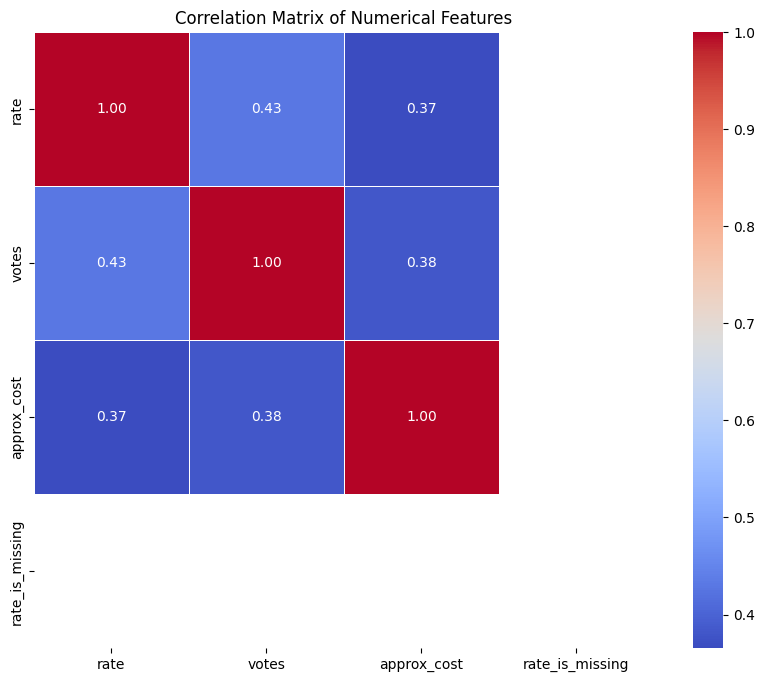

In [131]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=[np.number])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

print("Correlation Matrix for Numerical Columns:")
display(correlation_matrix)

# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [124]:
of analysis that and give me code to summarze best model

## 7. Model Summary and Best Model Identification

We have implemented and evaluated several models for two distinct tasks:

1.  **Regression (Predicting 'rate'):** Linear Regression, Ridge Regression, Lasso Regression, and XGBoost Regression.
2.  **Classification (Predicting 'online_order'):** Logistic Regression.

Let's summarize their performance:

### Regression Models for 'rate' Prediction:

| Model                  | MAE     | RMSE    | R2 Score |
| :--------------------- | :------ | :------ | :------- |
| Linear Regression      | 0.2453  | 0.3258  | 0.3126   |
| Ridge Regression       | 0.2453  | 0.3258  | 0.3127   |
| Lasso Regression       | 0.2533  | 0.3419  | 0.2431   |
| **XGBoost Regression** | **0.1661** | **0.2591** | **0.5653** |

**Observation:** For the regression task, **XGBoost Regression** clearly outperforms the other models, achieving the lowest MAE and RMSE, and the highest R2 score. This indicates it explains the most variance in the 'rate' column and has the lowest prediction errors.

### Classification Model for 'online_order' Prediction:

| Model                  | Accuracy | Precision | Recall | F1-Score | Log Loss |
| :--------------------- | :------- | :-------- | :----- | :------- | :------- |
| **Logistic Regression**| **0.6830** | **0.7024** | **0.8075** | **0.7513** | **0.5921** |

**Observation:** The Logistic Regression model achieved an accuracy of approximately 68.3% in predicting whether an online order is available. Its recall is relatively high, suggesting it's good at identifying instances of 'Yes' for online orders, while precision is slightly lower, indicating some false positives.


In [132]:
# Summarize best models and their metrics

best_regression_model = {
    'name': 'XGBoost Regression',
    'model_object': xgb_model,
    'metrics': {
        'MAE': mae_xgb,
        'RMSE': rmse_xgb,
        'R2 Score': r2_xgb
    }
}

best_classification_model = {
    'name': 'Logistic Regression',
    'model_object': log_reg_model,
    'metrics': {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Log Loss': logloss
    }
}

print("Best Regression Model:")
display(best_regression_model)

print("\nBest Classification Model:")
display(best_classification_model)

Best Regression Model:


{'name': 'XGBoost Regression',
 'model_object': XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...),
 'metrics': {'MAE': 0.16613441272510246,
  'RMSE': np.float64(0.2590779647084646),
  'R2 Score': 0.5653018829841714}}


Best Classification Model:


{'name': 'Logistic Regression',
 'model_object': LogisticRegression(max_iter=500, random_state=42, solver='liblinear'),
 'metrics': {'Accuracy': 0.6829576369996113,
  'Precision': 0.7023945267958951,
  'Recall': 0.8074717352121907,
  'F1-Score': 0.7512767741443708,
  'Log Loss': 0.5920963395352989}}

## 8. Save Cleaned Data to CSV

In [133]:
# Define the path to save the cleaned CSV file in Google Drive
cleaned_drive_file_path = '/content/drive/MyDrive/BDA PROJECT/zomato_cleaned.csv'

# Save the DataFrame to a CSV file without the index
df.to_csv(cleaned_drive_file_path, index=False)

print(f"Cleaned data saved successfully to '{cleaned_drive_file_path}'")

Cleaned data saved successfully to '/content/drive/MyDrive/BDA PROJECT/zomato_cleaned.csv'
